# 02 · How long do streaks last? (survival analysis)

The app shows a 🔥 streak: consecutive days at 100. Two questions:

1. How long does a typical streak survive, and who keeps it longer?
2. Do streaks **build habits** (the longer you go, the less likely you break), or do long
   streaks just belong to people who were always going to keep them?

Streaks are durations with **right-censoring** (some are still alive when data ends), so this is
a survival problem: Kaplan-Meier curves and a Cox model.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from onemore_analysis import SimConfig, simulate
from onemore_analysis.plotting import use_style, subtitle, date_axis, SERIES, REFERENCE, MUTED, INK_SECONDARY, GRID

use_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
from lifelines import CoxPHFitter, KaplanMeierFitter
from onemore_analysis.features import complete_panel, streak_spells

In [2]:
cfg = SimConfig()
sim = simulate(cfg)
panel = complete_panel(sim.daily, sim.users)

# Baseline commitment = completion rate in the first 2 weeks. Only streaks that start
# afterwards are analysed, so the covariate is measured before the outcome.
BASELINE_DAYS = 14
first = panel[panel["day"] < panel["day"].min() + np.timedelta64(BASELINE_DAYS, "D")]
baseline = first.groupby("user_id")["completed"].mean().rename("baseline_rate")

# terciles of *users* (not of streaks, or users with many streaks would weigh more)
commitment = pd.qcut(baseline.rank(method="first"), 3, labels=["low", "medium", "high"]).rename("commitment")
spells = streak_spells(panel, min_start_day=BASELINE_DAYS).join(baseline, on="user_id").join(commitment, on="user_id")
spells = spells.join(sim.users.set_index("user_id")["group_id"], on="user_id")
spells["group_size"] = spells["group_id"].map(sim.users["group_id"].value_counts())
spells["weekend_start"] = spells["start"].dt.dayofweek >= 5
print(f"{len(spells):,} streaks · {spells['event'].mean():.0%} broken, {1 - spells['event'].mean():.0%} censored")
spells.head()

1,018 streaks · 98% broken, 2% censored


,user_id,start,length,event,start_day,baseline_rate,commitment,group_id,group_size,weekend_start
0,0,2026-01-26,2,1,21,0.5,medium,0,4,False
1,0,2026-01-30,1,1,25,0.5,medium,0,4,False
2,0,2026-02-01,5,1,27,0.5,medium,0,4,True
3,0,2026-02-07,1,1,33,0.5,medium,0,4,True
4,0,2026-02-11,3,1,37,0.5,medium,0,4,False


## Kaplan-Meier: probability a streak is still alive after *n* days

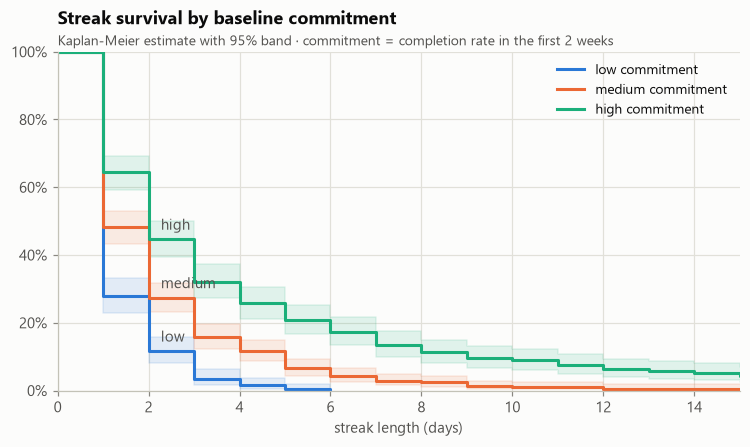

,users,streaks,median length (days),P(alive after 3 days),P(alive after 7 days)
commitment,,,,,
low,20,276,1.0,0.035,0.000
medium,20,407,1.0,0.158,0.029
high,20,335,2.0,0.322,0.135


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
rows = []
for color, level in zip(SERIES, ["low", "medium", "high"]):
    s = spells[spells["commitment"] == level]
    km = KaplanMeierFitter().fit(s["length"], s["event"], label=f"{level} commitment")
    km.plot_survival_function(ax=ax, color=color, ci_alpha=0.12, linewidth=2)
    y = km.survival_function_at_times(2).iloc[0]  # direct label where the curves are well apart
    ax.annotate(level, (2, y), xytext=(8, 4), textcoords="offset points", color=INK_SECONDARY, va="bottom")
    rows.append({"commitment": level, "users": s["user_id"].nunique(), "streaks": len(s),
                 "median length (days)": km.median_survival_time_,
                 "P(alive after 3 days)": km.survival_function_at_times(3).iloc[0],
                 "P(alive after 7 days)": km.survival_function_at_times(7).iloc[0]})
ax.set_xlim(0, 15)
ax.set_ylim(0, 1)
ax.set_xlabel("streak length (days)")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="upper right")
ax.set_title("Streak survival by baseline commitment", pad=18)
subtitle(ax, "Kaplan-Meier estimate with 95% band · commitment = completion rate in the first 2 weeks")
plt.show()
pd.DataFrame(rows).set_index("commitment")

## Cox proportional hazards

Hazard ratios below 1 mean a *lower* risk of breaking the streak. Standard errors are
clustered by user, since each user contributes many streaks.

In [4]:
cox_df = spells[["length", "event", "baseline_rate", "group_size", "weekend_start", "user_id"]].copy()
cox_df["baseline_rate_10pp"] = cox_df.pop("baseline_rate") * 10  # per +10 percentage points
cox_df["weekend_start"] = cox_df["weekend_start"].astype(int)
cph = CoxPHFitter().fit(cox_df, duration_col="length", event_col="event", cluster_col="user_id")
cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].rename(columns={"exp(coef)": "hazard ratio"})

,hazard ratio,exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
group_size,0.986,0.937,1.036,5.697e-01
weekend_start,0.947,0.839,1.069,3.743e-01
baseline_rate_10pp,0.836,0.803,0.869,5.516e-19


## Habit or selection?

The daily risk of breaking a streak falls as the streak gets longer. That looks like
*habit formation*, but it could equally be **selection**: long streaks are over-represented
among highly motivated users, who break less on every day (unobserved heterogeneity, or
"frailty").

With real data you could not tell the two apart from this curve alone. With the simulator
we can: rerun the exact same world with `habit_strength = 0`.

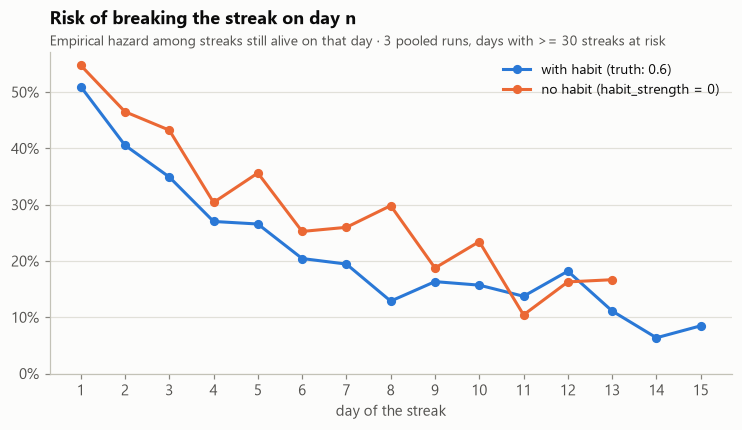

with habit (truth: 0.6)         no habit (habit_strength = 0)        
                     hazard at_risk                        hazard at_risk
day                                                                      
1                     0.510    2940                         0.548  3548.0
2                     0.406    1408                         0.465  1563.0
3                     0.349     822                         0.432   821.0
4                     0.270     533                         0.304   464.0
5                     0.266     384                         0.356   320.0
6                     0.204     279                         0.252   206.0
7                     0.194     216                         0.260   154.0
8                     0.129     171                         0.298   114.0
9                     0.163     147                         0.188    80.0
10                    0.157     121                         0.234    64.0
11                    0.137     102                         0.104    48.0
12                    0.182      88                         0.163    43.0
13                    0.111      72                         0.167    36.0
14                    0.063      63                           NaN     NaN
15                    0.085      59                           NaN     NaN

In [5]:
def break_hazard(spells, max_len=15, min_at_risk=30):
    """Life table: P(break on day k | streak alive on day k), only where enough streaks remain."""
    out = []
    for k in range(1, max_len + 1):
        at_risk = (spells["length"] >= k).sum()
        if at_risk < min_at_risk:
            break
        broke = ((spells["length"] == k) & (spells["event"] == 1)).sum()
        out.append((k, broke / at_risk, at_risk))
    return pd.DataFrame(out, columns=["day", "hazard", "at_risk"]).set_index("day")

# three independent runs per world, pooled, so the tail is not pure noise
worlds = {"with habit (truth: 0.6)": {}, "no habit (habit_strength = 0)": {"habit_strength": 0.0}}
hazards = {}
for name, kw in worlds.items():
    runs = []
    for seed in (7, 8, 9):
        s = simulate(SimConfig(seed=seed, **kw))
        runs.append(streak_spells(complete_panel(s.daily, s.users), min_start_day=BASELINE_DAYS))
    hazards[name] = break_hazard(pd.concat(runs, ignore_index=True))

fig, ax = plt.subplots(figsize=(8, 3.8))
for color, (name, h) in zip(SERIES, hazards.items()):
    ax.plot(h.index, h["hazard"], color=color, marker="o", markersize=5, label=name)
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_xlabel("day of the streak")
ax.set_xticks(range(1, 16))
ax.legend()
ax.set_title("Risk of breaking the streak on day n", pad=18)
subtitle(ax, "Empirical hazard among streaks still alive on that day · 3 pooled runs, days with >= 30 streaks at risk")
plt.show()
pd.concat({k: v for k, v in hazards.items()}, axis=1).round(3)

## Takeaways

* A typical streak is short, and baseline commitment is by far the strongest predictor of
  keeping it: the Cox model puts a large protective effect on each +10 pp of early completion.
* **The falling hazard is not proof of habit formation.** Even in the world with *no* habit
  effect the curve declines, because long streaks select motivated users. The gap between the
  two curves is the actual habit effect. On real data, separating them needs within-user
  variation (e.g. a frailty / mixed-effects survival model) or an experiment.

Next: [03 · Will they make it today?](03_completion_model.ipynb)